# K-Means Clustering from Scratch

This notebook implements the K-Means clustering algorithm from scratch using NumPy and Matplotlib.

## Mathematical/Algorithmic Intuition
K-Means is an unsupervised learning algorithm that partitions $m$ samples into $K$ clusters:
1. Initialize $K$ centroids randomly or by selecting $K$ samples.
2. **Assignment Step**: Assign each sample to its nearest centroid:
   $$c^{(i)} := \arg\min_{k} ||x^{(i)} - \mu_k||^2$$
3. **Update Step**: Recompute the centroids as the mean of all samples assigned to each cluster:
   $$\mu_k := \frac{\sum_{i=1}^{m} \mathbb{I}(c^{(i)} = k) x^{(i)}}{\sum_{i=1}^{m} \mathbb{I}(c^{(i)} = k)}$$
4. Repeat steps 2 & 3 until convergence (centroids do not change).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

## Generate Clustered Data

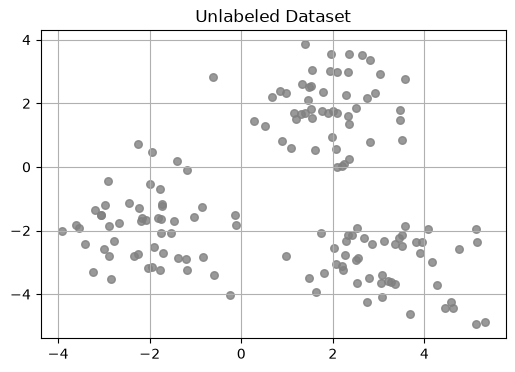

In [2]:
# Generate 3 distinct blobs
c1 = np.random.randn(50, 2) + np.array([2, 2])
c2 = np.random.randn(50, 2) + np.array([-2, -2])
c3 = np.random.randn(50, 2) + np.array([3, -3])
X = np.vstack([c1, c2, c3])

plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], color='gray', s=30, alpha=0.8)
plt.title('Unlabeled Dataset')
plt.grid(True)
plt.show()

## K-Means Implementation

In [3]:
class KMeansFromScratch:
    def __init__(self, k=3, max_iters=100):
        self.k = k
        self.max_iters = max_iters
        self.centroids = None
        
    def fit(self, X):
        n_samples, n_features = X.shape
        
        # Randomly initialize centroids
        random_idx = np.random.choice(n_samples, self.k, replace=False)
        self.centroids = X[random_idx]
        
        for i in range(self.max_iters):
            # Step 1: Assign clusters
            labels = self._create_clusters(X)
            
            old_centroids = self.centroids.copy()
            
            # Step 2: Update centroids
            self.centroids = self._get_centroids(X, labels)
            
            # Check convergence
            if np.all(old_centroids == self.centroids):
                print(f"Converged at iteration {i}")
                break
                
        return labels
        
    def _create_clusters(self, X):
        # Distances from each point to each centroid
        distances = np.array([np.sqrt(np.sum((X - c) ** 2, axis=1)) for c in self.centroids])
        # Distance shape is (K, n_samples)
        return np.argmin(distances, axis=0)
        
    def _get_centroids(self, X, labels):
        centroids = np.zeros((self.k, X.shape[1]))
        for i in range(self.k):
            points = X[labels == i]
            if len(points) > 0:
                centroids[i] = np.mean(points, axis=0)
            else:
                # Keep old centroid if no points assigned
                centroids[i] = self.centroids[i]
        return centroids

## Run Clustering & Plot Results

Converged at iteration 3


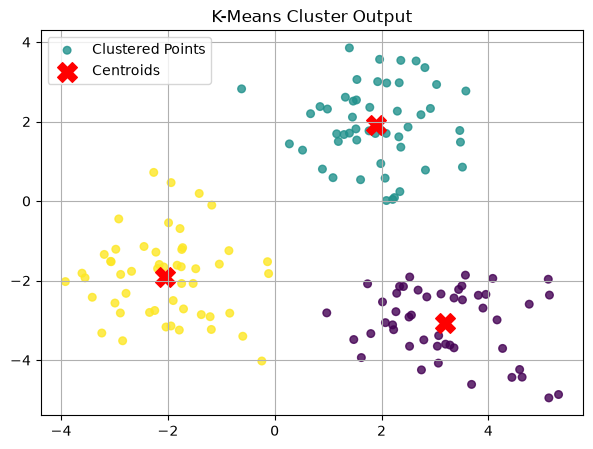

In [4]:
model = KMeansFromScratch(k=3)
labels = model.fit(X)

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=30, alpha=0.8, label='Clustered Points')
plt.scatter(model.centroids[:, 0], model.centroids[:, 1], color='red', marker='X', s=200, label='Centroids')
plt.title('K-Means Cluster Output')
plt.legend()
plt.grid(True)
plt.show()